#sBLOOM: Embedding cell type annotation tutorial

The scBLOOM framework enables a variety of downstream tasks. This tutorial gives an example on how to perform cell type annotation with the embeddings produced by following the initial guide on running the framework.

First, install all the necessary dependencies

In [86]:
%pip install torch pandas numpy scikit-learn matplotlib seaborn scanpy

Note: you may need to restart the kernel to use updated packages.


#Import packages and define functions

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from torch.utils.data import DataLoader, TensorDataset
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
import sys
import os
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import scanpy as sc

class Classifier(nn.Module):
    def __init__(self, input_size, num_classes):
        super(Classifier, self).__init__()
        
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.GELU(),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.GELU(),
            nn.Dropout(0.1),

            nn.Linear(32, num_classes)
        )
    
    def forward(self, x):
        return self.net(x)


In [20]:
Methods_dic={
    'scNET' : (15, 'Blues'),
    'scGPT' : (6, 'Oranges'),
    'avg' : (8, 'Reds'),
    'conq' : (6, 'Reds')
}


def test_embeddings( cell_embeddings, labels, method, save_dir):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    num_folds = 5
    skf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)
    X = cell_embeddings
    y = labels
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y)

    fold_accuracies = []
    fold_precisions = []
    fold_recalls = []
    fold_f1s = []
    fold_losses = []

    all_y_true = []
    all_y_pred = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        if method == "conq":
            pca = PCA(n_components=512)
            pca.fit(X_train)
            X_train = pca.transform(X_train)
            X_test = pca.transform(X_test)

        X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
        X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
        y_train_tensor = torch.tensor(y_train, dtype=torch.long)
        y_test_tensor = torch.tensor(y_test, dtype=torch.long)

        train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
        train_loader = DataLoader(train_dataset, batch_size = 32, shuffle=True, drop_last=False)

        # Initialize model
        input_size = X_train.shape[1]
        num_classes = len(np.unique(y))
        model = Classifier(input_size, num_classes).to(device)

        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001)

        # Train the model
        num_epochs = Methods_dic[method][0]
        for epoch in range(num_epochs):
            model.train()
            total_loss = 0
            correct_predictions = 0
            total_predictions = 0
            
            for batch_X, batch_y in train_loader:
                
                batch_X = batch_X.to(device)
                batch_y = batch_y.to(device)
                
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)

                _, predicted_labels = torch.max(outputs, 1)
                correct_predictions += (predicted_labels == batch_y).sum().item()
                total_predictions += batch_y.size(0)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                total_loss += loss.item()
            
            accuracy = correct_predictions / total_predictions

            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss/len(train_loader):.4f}, Accuracy: {accuracy:.4f}")


        model.eval()
        with torch.inference_mode():
            X_test_tensor = X_test_tensor.to(device)
            y_test_tensor = y_test_tensor.to(device)
            
            outputs = model(X_test_tensor)
            test_loss = criterion(outputs, y_test_tensor)

            _, predicted = torch.max(outputs, 1)
            y_true = y_test_tensor.cpu().numpy()
            y_pred = predicted.cpu().numpy()

            accuracy = accuracy_score(y_true, y_pred)
            precision = precision_score(y_true, y_pred, average="macro", zero_division=1)
            recall = recall_score(y_true, y_pred, average="macro")
            f1 = f1_score(y_true, y_pred, average="macro")
            
            print(f"Fold {fold+1}: Accuracy={accuracy:.4f}, Precision={precision:.4f}, Recall={recall:.4f}, F1-Score={f1:.4f}")

            fold_losses.append(test_loss.item())
            fold_accuracies.append(accuracy)
            fold_precisions.append(precision)
            fold_recalls.append(recall)
            fold_f1s.append(f1)

            all_y_true.extend(y_true)
            all_y_pred.extend(y_pred)

    print("\nFinal Cross-Validation Results:")
    print(f"Mean Loss: {np.mean(fold_losses):.4f} ± {np.std(fold_losses):.4f}")
    print(f"Mean Accuracy: {np.mean(fold_accuracies):.4f} ± {np.std(fold_accuracies):.4f}")
    print(f"Mean Precision: {np.mean(fold_precisions):.4f} ± {np.std(fold_precisions):.4f}")
    print(f"Mean Recall: {np.mean(fold_recalls):.4f} ± {np.std(fold_recalls):.4f}")
    print(f"Mean F1-Score: {np.mean(fold_f1s):.4f} ± {np.std(fold_f1s):.4f}")

    true_labels_decoded = label_encoder.inverse_transform(np.array(all_y_true))
    pred_labels_decoded = label_encoder.inverse_transform(np.array(all_y_pred))

    make_conf_matrix(true_labels_decoded, pred_labels_decoded, label_encoder.classes_, save_dir, Methods_dic[method][1], method)

    del model, optimizer, criterion
    torch.cuda.empty_cache()



def make_conf_matrix(y_true, y_pred, labels, save_dir, color, name):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_normalized = cm.astype("float") / cm.sum(axis=1, keepdims=True)
    cm_df = pd.DataFrame(
        cm_normalized,
        index=labels,
        columns=labels
    )
    plt.figure(figsize=(6, 5))
    ax = sns.heatmap(
        cm_df,
        annot=True,
        fmt=".2f",
        cmap=color,
        cbar_kws={"shrink": 0.75},
        annot_kws={"size": 9}
    )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
    ax.set_xlabel("Predicted Label", fontsize=9)
    ax.set_ylabel("True Label", fontsize=9)
    
    plt.tight_layout()
    plt.show()
    plt.close()


#Classify embeddings

The initial guide should produce a "test" directory with the output embeddings of the PBMC dataset. A separate classification will be performed for all the models, mainly scNET, scGPT, and scBLOOM (averaged and concatenated).

In [5]:
obj = sc.read("../output/test/scBLOOM/Embs.h5ad")

Using device: cpu
Epoch 1/15, Loss: 1.4531, Accuracy: 0.6801
Epoch 2/15, Loss: 0.9482, Accuracy: 0.8969
Epoch 3/15, Loss: 0.6935, Accuracy: 0.9111
Epoch 4/15, Loss: 0.5371, Accuracy: 0.9265
Epoch 5/15, Loss: 0.4353, Accuracy: 0.9230
Epoch 6/15, Loss: 0.3583, Accuracy: 0.9336
Epoch 7/15, Loss: 0.3015, Accuracy: 0.9443
Epoch 8/15, Loss: 0.2898, Accuracy: 0.9360
Epoch 9/15, Loss: 0.2809, Accuracy: 0.9348
Epoch 10/15, Loss: 0.2500, Accuracy: 0.9360
Epoch 11/15, Loss: 0.2151, Accuracy: 0.9502
Epoch 12/15, Loss: 0.1954, Accuracy: 0.9526
Epoch 13/15, Loss: 0.1712, Accuracy: 0.9538
Epoch 14/15, Loss: 0.1771, Accuracy: 0.9609
Epoch 15/15, Loss: 0.1885, Accuracy: 0.9479
Fold 1: Accuracy=0.9434, Precision=0.9448, Recall=0.9106, F1-Score=0.9225
Epoch 1/15, Loss: 1.4703, Accuracy: 0.7254
Epoch 2/15, Loss: 0.9433, Accuracy: 0.8947
Epoch 3/15, Loss: 0.7012, Accuracy: 0.9160
Epoch 4/15, Loss: 0.5341, Accuracy: 0.9254
Epoch 5/15, Loss: 0.4240, Accuracy: 0.9254
Epoch 6/15, Loss: 0.3630, Accuracy: 0.9373

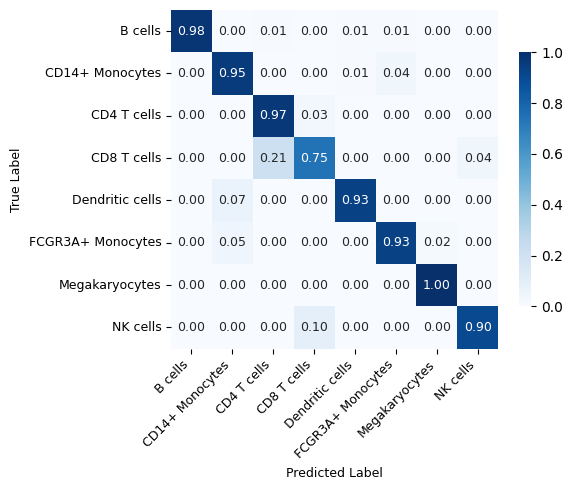

In [ ]:
test_embeddings(obj.obsm['X_scnet'], obj.obs['celltype'], "scNET", "output")

Using device: cpu
Epoch 1/6, Loss: 1.1651, Accuracy: 0.8460
Epoch 2/6, Loss: 0.7137, Accuracy: 0.9289
Epoch 3/6, Loss: 0.5333, Accuracy: 0.9348
Epoch 4/6, Loss: 0.4099, Accuracy: 0.9396
Epoch 5/6, Loss: 0.3296, Accuracy: 0.9396
Epoch 6/6, Loss: 0.2840, Accuracy: 0.9467
Fold 1: Accuracy=0.9481, Precision=0.9480, Recall=0.9523, F1-Score=0.9490
Epoch 1/6, Loss: 1.1733, Accuracy: 0.8769
Epoch 2/6, Loss: 0.7843, Accuracy: 0.9290
Epoch 3/6, Loss: 0.5515, Accuracy: 0.9361
Epoch 4/6, Loss: 0.4132, Accuracy: 0.9444
Epoch 5/6, Loss: 0.3519, Accuracy: 0.9420
Epoch 6/6, Loss: 0.3000, Accuracy: 0.9408
Fold 2: Accuracy=0.9289, Precision=0.8999, Recall=0.9472, F1-Score=0.9206
Epoch 1/6, Loss: 1.1850, Accuracy: 0.8627
Epoch 2/6, Loss: 0.7783, Accuracy: 0.9408
Epoch 3/6, Loss: 0.5520, Accuracy: 0.9420
Epoch 4/6, Loss: 0.4364, Accuracy: 0.9396
Epoch 5/6, Loss: 0.3455, Accuracy: 0.9467
Epoch 6/6, Loss: 0.3153, Accuracy: 0.9467
Fold 3: Accuracy=0.9336, Precision=0.9402, Recall=0.8984, F1-Score=0.9149
Epoc

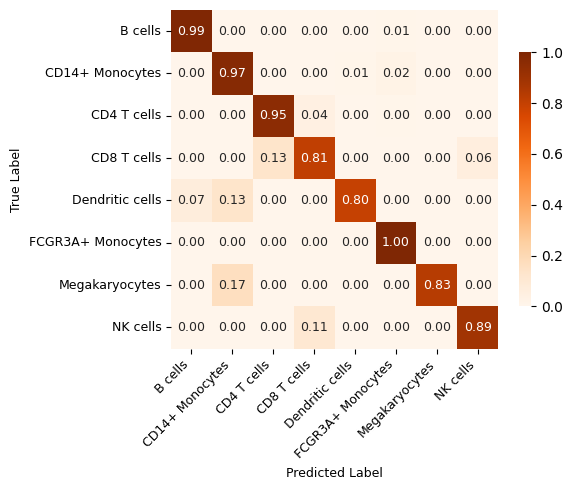

In [21]:
test_embeddings(obj.obsm['X_scgpt'], obj.obs['celltype'], "scGPT", "output")

Using device: cpu
Epoch 1/8, Loss: 1.2747, Accuracy: 0.8258
Epoch 2/8, Loss: 0.7679, Accuracy: 0.9313
Epoch 3/8, Loss: 0.5567, Accuracy: 0.9360
Epoch 4/8, Loss: 0.4172, Accuracy: 0.9479
Epoch 5/8, Loss: 0.3318, Accuracy: 0.9431
Epoch 6/8, Loss: 0.2881, Accuracy: 0.9502
Epoch 7/8, Loss: 0.2527, Accuracy: 0.9455
Epoch 8/8, Loss: 0.2265, Accuracy: 0.9550
Fold 1: Accuracy=0.9434, Precision=0.9414, Recall=0.9052, F1-Score=0.9182
Epoch 1/8, Loss: 1.2048, Accuracy: 0.8237
Epoch 2/8, Loss: 0.7273, Accuracy: 0.9337
Epoch 3/8, Loss: 0.4940, Accuracy: 0.9527
Epoch 4/8, Loss: 0.3720, Accuracy: 0.9527
Epoch 5/8, Loss: 0.3047, Accuracy: 0.9479
Epoch 6/8, Loss: 0.2489, Accuracy: 0.9562
Epoch 7/8, Loss: 0.2196, Accuracy: 0.9586
Epoch 8/8, Loss: 0.1941, Accuracy: 0.9657
Fold 2: Accuracy=0.9289, Precision=0.9035, Recall=0.9363, F1-Score=0.9169
Epoch 1/8, Loss: 1.1812, Accuracy: 0.8367
Epoch 2/8, Loss: 0.7072, Accuracy: 0.9314
Epoch 3/8, Loss: 0.5237, Accuracy: 0.9314
Epoch 4/8, Loss: 0.3878, Accuracy: 0

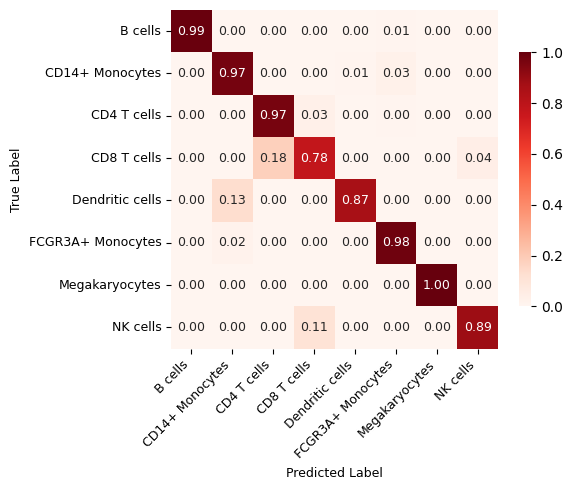

In [91]:
test_embeddings(obj.obsm['X_combined_avg'], obj.obs['celltype'], "avg", "output")

Using device: cpu
Epoch 1/6, Loss: 1.3354, Accuracy: 0.7464
Epoch 2/6, Loss: 0.7841, Accuracy: 0.9348
Epoch 3/6, Loss: 0.5165, Accuracy: 0.9479
Epoch 4/6, Loss: 0.3503, Accuracy: 0.9585
Epoch 5/6, Loss: 0.2713, Accuracy: 0.9727
Epoch 6/6, Loss: 0.2044, Accuracy: 0.9846
Fold 1: Accuracy=0.9434, Precision=0.9460, Recall=0.9473, F1-Score=0.9452
Epoch 1/6, Loss: 1.5042, Accuracy: 0.6556
Epoch 2/6, Loss: 0.8474, Accuracy: 0.9278
Epoch 3/6, Loss: 0.5358, Accuracy: 0.9432
Epoch 4/6, Loss: 0.3732, Accuracy: 0.9550
Epoch 5/6, Loss: 0.2666, Accuracy: 0.9740
Epoch 6/6, Loss: 0.2135, Accuracy: 0.9834
Fold 2: Accuracy=0.9336, Precision=0.9048, Recall=0.9268, F1-Score=0.9130
Epoch 1/6, Loss: 1.4437, Accuracy: 0.7349
Epoch 2/6, Loss: 0.8007, Accuracy: 0.9349
Epoch 3/6, Loss: 0.5531, Accuracy: 0.9503
Epoch 4/6, Loss: 0.3646, Accuracy: 0.9574
Epoch 5/6, Loss: 0.2776, Accuracy: 0.9669
Epoch 6/6, Loss: 0.2133, Accuracy: 0.9811
Fold 3: Accuracy=0.9336, Precision=0.9390, Recall=0.9021, F1-Score=0.9149
Epoc

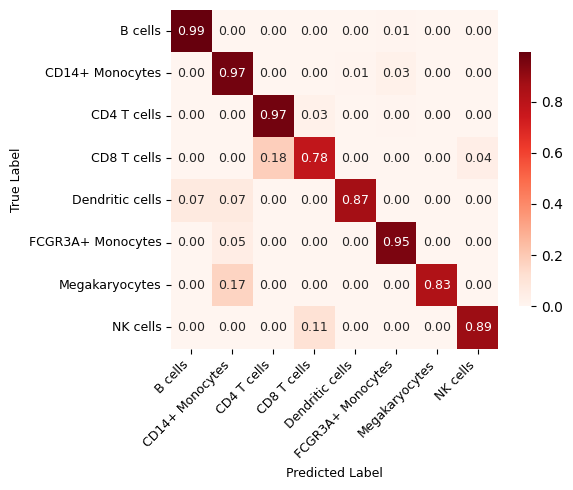

In [19]:
test_embeddings(obj.obsm['X_combined_conc'], obj.obs['celltype'], "conq", "output")